# 02 · EDA e insights de negócio

**Previsão de atraso de entrega no e-commerce brasileiro (Olist)** · Notebook 2 de 3

Este notebook consome a tabela mestra construída por `src/data_prep.py` (etapa 2) e responde perguntas de negócio sobre o atraso de entrega. **Método:** cada seção começa com a pergunta escrita ANTES da figura e termina com a resposta e o mecanismo; nenhuma figura órfã. Ao final, a segmentação de vendedores em personas (K-Means) e a lista candidata de features para a modelagem (etapa 4).

Taxa global de referência: **6,77% dos 96.470 pedidos entregues** (medida no notebook 01 e reproduzida pelo pipeline).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

master = pd.read_parquet(ROOT / "data" / "processed" / "master_table.parquet")
GLOBAL_RATE = master["is_late"].mean()

assert len(master) == 96_470 and master["order_id"].is_unique
print(f"tabela mestra: {len(master):,} pedidos · taxa de atraso {GLOBAL_RATE:.2%}")

tabela mestra: 96,470 pedidos · taxa de atraso 6.77%


In [2]:
# Validated categorical palette (fixed order); single-hue charts use slot 1.
C1, C2, C3, C4 = "#2a78d6", "#1baf7a", "#eda100", "#008300"
ACCENT, GRAY, INK = C1, "#898781", "#0b0b0b"

plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.8,
        "axes.edgecolor": GRAY,
        "axes.labelcolor": "#52514e",
        "xtick.color": GRAY,
        "ytick.color": GRAY,
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
    }
)


def rate_by(df: pd.DataFrame, key, min_n: int = 0) -> pd.DataFrame:
    # Late rate (%) and volume per group, optionally filtering small groups.
    out = df.groupby(key, observed=True)["is_late"].agg(n="size", rate="mean")
    out["rate"] = 100 * out["rate"]
    return out[out["n"] >= min_n]


def bin_labels(intervals, fmt: str = "{:.0f}") -> list[str]:
    # Human-readable labels for qcut intervals.
    return [f"{fmt.format(iv.left)}–{fmt.format(iv.right)}" for iv in intervals]


def add_global_line(ax) -> None:
    ax.axhline(100 * GLOBAL_RATE, color=GRAY, linewidth=1, linestyle="--")
    ax.annotate(
        f"média global {100 * GLOBAL_RATE:.1f}%",
        xy=(1.0, 100 * GLOBAL_RATE),
        xycoords=("axes fraction", "data"),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        fontsize=8,
        color=GRAY,
    )

## P1. A taxa de atraso é estável ao longo do tempo?

**Por que importa:** se o atraso tem picos sazonais ou choques, o mês da compra é feature candidata, e a avaliação do modelo precisa ser estratificada no tempo (é a base da narrativa de drift da etapa 5).

Meses com menos de 100 pedidos (set/2016 com 1 pedido, dez/2016 com 1) ficam fora da figura para não plotar ruído.

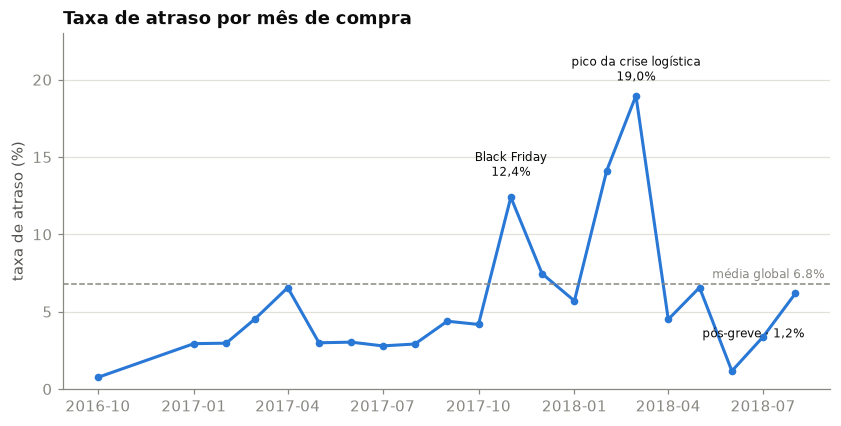

,n,rate
purchase_year_month,,
2018-01,7069,5.70
2018-02,6555,14.13
2018-03,7003,18.96
2018-04,6798,4.50
2018-05,6749,6.56
2018-06,6096,1.16
2018-07,6156,3.38
2018-08,6351,6.19


In [3]:
monthly = rate_by(master, "purchase_year_month", min_n=100)
x = pd.to_datetime(monthly.index)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(x, monthly["rate"], color=ACCENT, linewidth=2, marker="o", markersize=4)
add_global_line(ax)

peaks = {
    "2017-11": ("Black Friday\n12,4%", (0, 14)),
    "2018-03": ("pico da crise logística\n19,0%", (0, 10)),
    "2018-06": ("pós-greve · 1,2%", (14, 22)),
}
for month, (label, offset) in peaks.items():
    xi = pd.Timestamp(month)
    yi = monthly.loc[month, "rate"]
    ax.annotate(
        label, xy=(xi, yi), xytext=offset, textcoords="offset points",
        ha="center", fontsize=8, color=INK,
    )

ax.set_title("Taxa de atraso por mês de compra")
ax.set_ylabel("taxa de atraso (%)")
ax.set_ylim(0, 23)
plt.show()

monthly.tail(8).round(2)

**Resposta: não, e os desvios são grandes.** A taxa mensal varia de ~3% a **19,0%**. Três episódios estruturam a série:

1. **Black Friday (nov/2017, 12,4%):** pico de demanda que satura a logística; compras de novembro atrasam quase o dobro da média.
2. **Crise logística de fev–mar/2018 (14,1% e 19,0%):** o maior choque da série, um período documentado de saturação de entregas na base Olist. Compras de março/2018 atrasaram quase 3x a média global.
3. **Pós-greve dos caminhoneiros (jun/2018, 1,2%):** depois do choque de maio, as estimativas prometidas foram visivelmente recalibradas para cima, derrubando a taxa de atraso, o atraso é sempre RELATIVO à promessa.

**Consequências:** `purchase_month` entra como feature; o corte temporal treino/teste (~mar/2018) coloca parte desse regime turbulento no teste, o que será narrado com estratificação mensal na etapa 5.

## P2. O atraso depende de para onde o pedido vai (UF de destino)?

**Por que importa:** distribuição geográfica desigual de malha logística é a hipótese mecânica mais óbvia do problema; se confirmada, UF e distância são features centrais e a operação sabe ONDE agir.

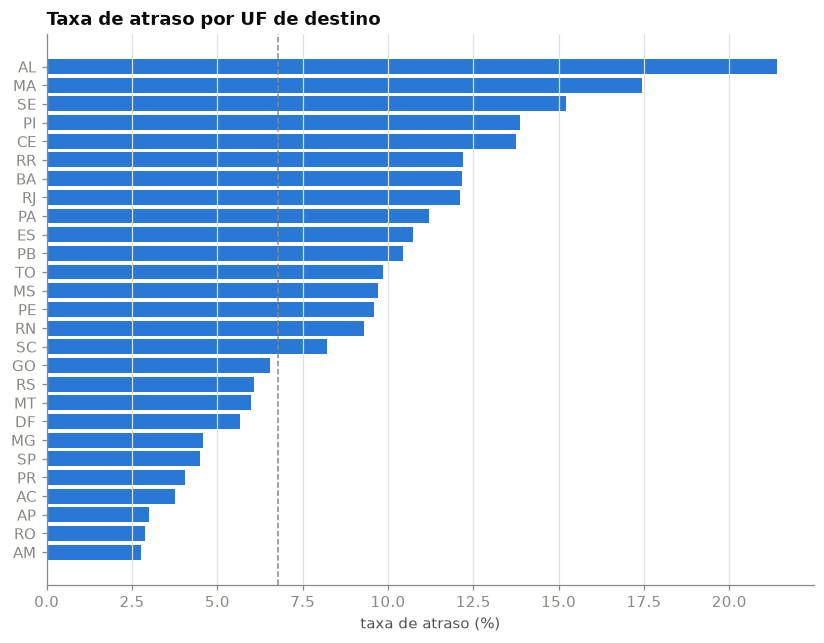

,n,rate
customer_state,,
AL,397,21.41
MA,717,17.43
SE,335,15.22
PI,476,13.87
CE,1279,13.76
AM,145,2.76
RO,243,2.88
AP,67,2.99


In [4]:
by_uf = rate_by(master, "customer_state").sort_values("rate")

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(by_uf.index, by_uf["rate"], color=ACCENT)
ax.axvline(100 * GLOBAL_RATE, color=GRAY, linewidth=1, linestyle="--")
ax.grid(axis="x", color="#e1e0d9")
ax.grid(axis="y", visible=False)
ax.set_title("Taxa de atraso por UF de destino")
ax.set_xlabel("taxa de atraso (%)")
plt.show()

pd.concat([by_uf.tail(5).iloc[::-1], by_uf.head(3)]).round(2)

**Resposta: sim, com amplitude de quase 5x entre extremos relevantes.** Alagoas (21,4%), Maranhão (17,4%) e Sergipe (15,2%) lideram; São Paulo, com 42% do volume, tem 4,5%. Duas leituras finas:

- **Rio de Janeiro é o caso de negócio mais importante:** 12.350 pedidos (2º maior volume) com taxa de 12,1%, quase 3x a de SP. Não é cauda estatística, é um mercado grande com desempenho ruim.
- UFs da ponta norte (RR com 41 pedidos, AP com 67, AC com 80) têm amostra pequena; suas taxas individuais não sustentam conclusão isolada.

**Consequência:** `customer_state` entra como feature (one-hot, decisão nº 15); a distância deve capturar parte do mesmo sinal, o que a P3 verifica.

## P3. Distância maior implica mais atraso?

**Por que importa:** é a feature geográfica contínua (haversine vendedor→cliente, construída na etapa 2). A hipótese mecânica: mais quilômetros = mais elos e transbordos = mais chances de falha.

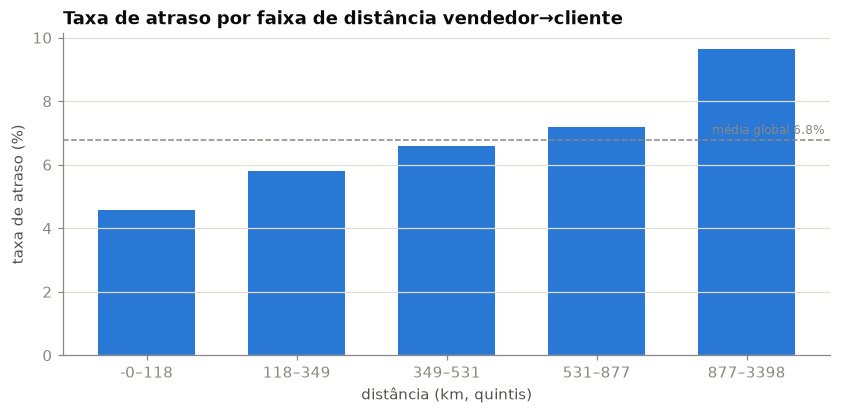

,n,rate
-0–118,19199,4.56
118–349,19198,5.81
349–531,19199,6.59
531–877,19198,7.18
877–3398,19199,9.65


In [5]:
dist_bins = pd.qcut(master["distance_km"], 5)
by_dist = rate_by(master.assign(bin=dist_bins), "bin")
by_dist.index = bin_labels(by_dist.index.categories)

fig, ax = plt.subplots()
ax.bar(by_dist.index, by_dist["rate"], color=ACCENT, width=0.65)
add_global_line(ax)
ax.set_title("Taxa de atraso por faixa de distância vendedor→cliente")
ax.set_xlabel("distância (km, quintis)")
ax.set_ylabel("taxa de atraso (%)")
plt.show()

by_dist.round(2)

**Resposta: sim, gradiente monotônico limpo.** De 4,6% no quintil mais próximo (até ~118 km) a 9,7% no mais distante (877 km ou mais), mais que o dobro. É o comportamento esperado do mecanismo físico e valida a decisão de construir a distância na etapa 2 (inclusive o cuidado com os centroides de geolocation). `distance_km` é feature confirmada.

## P4. Promessas mais apertadas atrasam mais?

**Por que importa:** a janela prometida (estimativa − compra, em dias) é a feature que representa o compromisso assumido com o cliente. A intuição ingênua diz: janela curta = promessa agressiva = mais atraso. Vamos ver se o dado concorda.

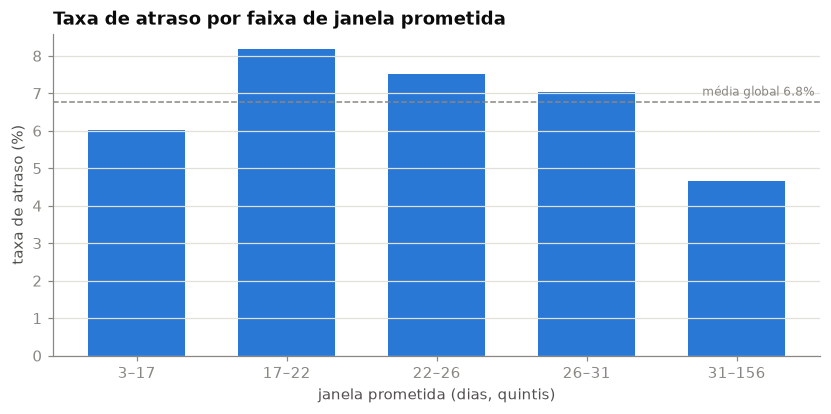

janela mediana por quintil de distância:
bin
(-0.001, 117.518]      15.0
(117.518, 348.648]     22.0
(348.648, 531.284]     24.0
(531.284, 877.313]     26.0
(877.313, 3398.486]    30.0


In [6]:
win_bins = pd.qcut(master["promised_window_days"], 5, duplicates="drop")
by_win = rate_by(master.assign(bin=win_bins), "bin")
by_win.index = bin_labels(by_win.index.categories)

fig, ax = plt.subplots()
ax.bar(by_win.index, by_win["rate"], color=ACCENT, width=0.65)
add_global_line(ax)
ax.set_title("Taxa de atraso por faixa de janela prometida")
ax.set_xlabel("janela prometida (dias, quintis)")
ax.set_ylabel("taxa de atraso (%)")
plt.show()

# Windows correlate with distance: median window per distance quintile.
print("janela mediana por quintil de distância:")
print(master.assign(bin=dist_bins).groupby("bin", observed=True)["promised_window_days"].median().to_string())

**Resposta: não, e a relação é não monotônica, o achado mais interessante da EDA.** As janelas mais curtas (até 17 dias) atrasam MENOS que a média (6,0%), o pior grupo é o intermediário de 17–22 dias (8,2%), e as janelas longas (31+ dias) são as mais seguras (4,7%).

**Mecanismo consistente com os dados:** a janela não é aleatória, ela é a própria previsão da plataforma, correlacionada com a dificuldade da rota (a janela mediana cresce de 15 para 30 dias do quintil de distância mais próximo ao mais distante). Janelas curtas só são prometidas onde a plataforma tem confiança (rotas fáceis); janelas longas carregam colchão generoso. O grupo intermediário parece ser onde a calibração é otimista demais: rotas medianamente difíceis com promessas sem colchão suficiente.

**Consequências:** `promised_window_days` entra como feature, e a não monotonicidade justifica modelos de árvore na comparação (a regressão logística só captura isso com engenharia adicional). Para a apresentação: "o atraso é sempre relativo à promessa, e a promessa erra mais no meio".

## P5. Algumas categorias de produto atrasam mais?

**Por que importa:** categoria é proxy de cadeia de suprimento (tamanho, fragilidade, tipo de vendedor). Apenas as 15 categorias de maior volume entram no ranking, taxa de categoria pequena é ruído.

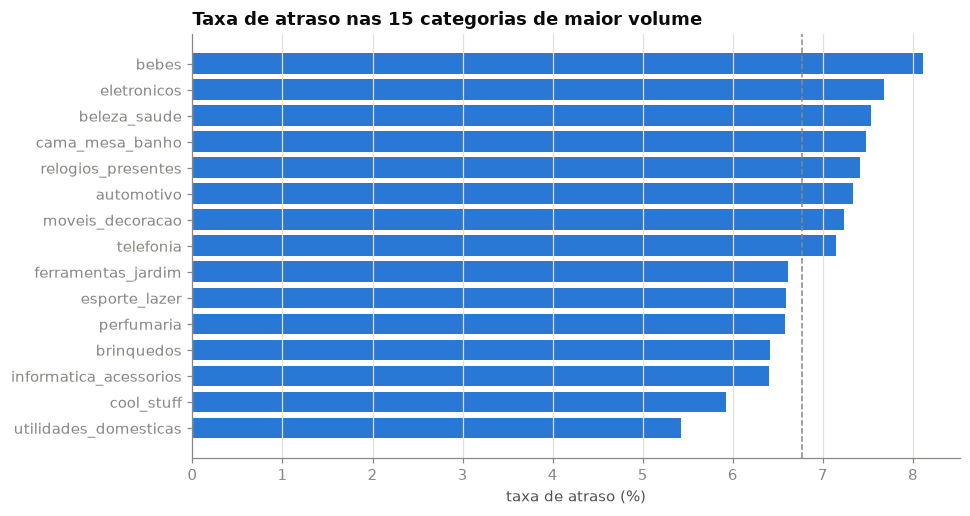

,n,rate
main_category,,
bebes,2761,8.11
eletronicos,2502,7.67
beleza_saude,8613,7.54


In [7]:
top15 = master["main_category"].value_counts().head(15).index
by_cat = rate_by(master[master["main_category"].isin(top15)], "main_category").sort_values("rate")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(by_cat.index, by_cat["rate"], color=ACCENT)
ax.axvline(100 * GLOBAL_RATE, color=GRAY, linewidth=1, linestyle="--")
ax.grid(axis="x", color="#e1e0d9")
ax.grid(axis="y", visible=False)
ax.set_title("Taxa de atraso nas 15 categorias de maior volume")
ax.set_xlabel("taxa de atraso (%)")
plt.show()

by_cat.tail(3).iloc[::-1].round(2)

**Resposta: sim, mas com amplitude moderada.** No top-15, a taxa varia de 5,4% (`utilidades_domesticas`) a 8,1% (`bebes`), cerca de 1,5x. O sinal existe e é consistente (categorias de itens volumosos/frágeis no topo), mas é bem mais fraco que geografia e tempo. `main_category` entra como feature de suporte, sem expectativa de protagonismo.

## P6. Frete caro em relação ao produto sinaliza logística difícil?

**Por que importa:** a razão frete/preço foi construída na etapa 2 com a hipótese de que frete proporcionalmente caro indica rota ou item problemático.

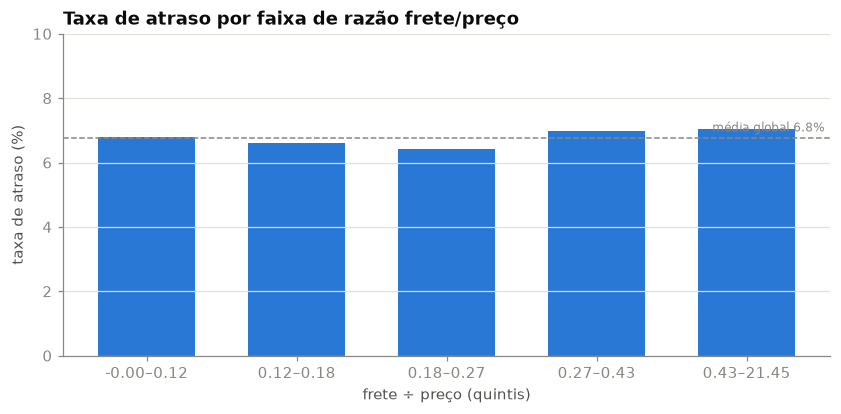

,n,rate
-0.00–0.12,19294,6.81
0.12–0.18,19294,6.61
0.18–0.27,19301,6.43
0.27–0.43,19296,6.97
0.43–21.45,19285,7.04


In [8]:
fr_bins = pd.qcut(master["freight_price_ratio"], 5)
by_fr = rate_by(master.assign(bin=fr_bins), "bin")
by_fr.index = bin_labels(by_fr.index.categories, "{:.2f}")

fig, ax = plt.subplots()
ax.bar(by_fr.index, by_fr["rate"], color=ACCENT, width=0.65)
add_global_line(ax)
ax.set_title("Taxa de atraso por faixa de razão frete/preço")
ax.set_xlabel("frete ÷ preço (quintis)")
ax.set_ylabel("taxa de atraso (%)")
ax.set_ylim(0, 10)
plt.show()

by_fr.round(2)

**Resposta: não isoladamente, hipótese não confirmada.** A taxa fica entre 6,4% e 7,0% em todos os quintis, praticamente plana. Registrado com honestidade: a razão frete/preço, sozinha, não discrimina atraso. Ela permanece na lista candidata apenas porque pode ter valor em INTERAÇÃO (ex.: frete caro numa rota curta), algo que os modelos de árvore testam de graça; se a importância sair nula na etapa 4, sai da conversa sem dor.

## P7. Pedidos mais pesados atrasam mais?

**Por que importa:** peso e volume mudam o modal e o manuseio; é a hipótese física complementar à distância.

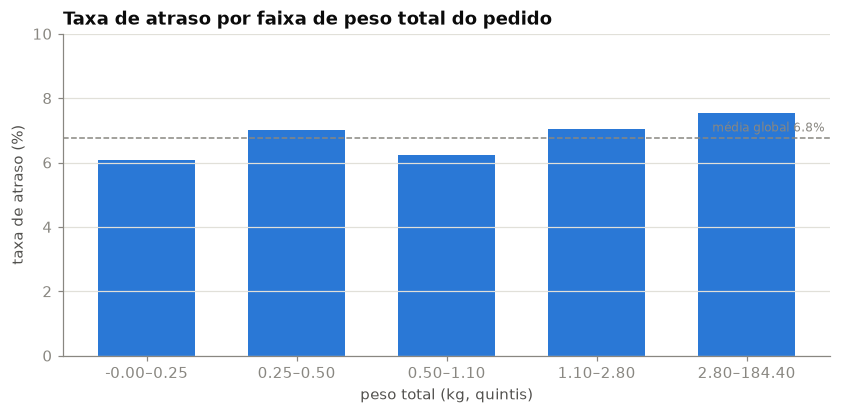

,n,rate
-0.00–0.25,20498,6.08
0.25–0.50,18331,7.02
0.50–1.10,19055,6.25
1.10–2.80,19419,7.03
2.80–184.40,19151,7.55


In [9]:
wt_bins = pd.qcut(master["total_weight_g"] / 1000, 5)
by_wt = rate_by(master.assign(bin=wt_bins), "bin")
by_wt.index = bin_labels(by_wt.index.categories, "{:.2f}")

fig, ax = plt.subplots()
ax.bar(by_wt.index, by_wt["rate"], color=ACCENT, width=0.65)
add_global_line(ax)
ax.set_title("Taxa de atraso por faixa de peso total do pedido")
ax.set_xlabel("peso total (kg, quintis)")
ax.set_ylabel("taxa de atraso (%)")
ax.set_ylim(0, 10)
plt.show()

by_wt.round(2)

**Resposta: levemente, sem gradiente limpo.** Do quintil mais leve (6,1%) ao mais pesado (7,5%) há inclinação modesta e não monotônica no meio. Peso e volume entram como features de suporte (custo zero, já estão na tabela mestra), com expectativa calibrada.

## P8. Pedidos com mais de um vendedor atrasam mais?

**Por que importa:** a intuição do elo mais fraco diz que sim: mais vendedores, mais chances de um falhar. Este é o teste da intuição contra o dado.

In [10]:
multi = master.assign(multi_seller=np.where(master["n_sellers"] > 1, "2+ vendedores", "1 vendedor"))
delivery_days = (
    master["order_delivered_customer_date"].dt.normalize()
    - master["order_purchase_timestamp"].dt.normalize()
).dt.days
multi["delivery_days"] = delivery_days
multi["slack_days"] = master["promised_window_days"] - delivery_days

summary = multi.groupby("multi_seller").agg(
    pedidos=("is_late", "size"),
    taxa_atraso_pct=("is_late", lambda s: round(100 * s.mean(), 2)),
    janela_prometida_mediana=("promised_window_days", "median"),
    entrega_real_mediana_dias=("delivery_days", "median"),
    folga_mediana_dias=("slack_days", "median"),
)
summary

,pedidos,taxa_atraso_pct,janela_prometida_mediana,entrega_real_mediana_dias,folga_mediana_dias
multi_seller,,,,,
1 vendedor,95195,6.85,24.0,10.0,12.0
2+ vendedores,1275,1.02,25.0,8.0,16.0


**Resposta: não, o contrário, e o mecanismo está na folga.** Pedidos multi-vendedor atrasam 1,0% contra 6,9% dos de vendedor único. A tabela desmonta o paradoxo: a promessa é praticamente igual (25 vs 24 dias medianos), mas a entrega real é MAIS RÁPIDA (8 vs 10 dias), sobrando folga mediana de 16 dias contra 12. A intuição do elo mais fraco vale para o processo físico, mas o resultado observado é dominado pela folga da promessa.

Hipótese plausível (não demonstrável nesta base): pedidos multi-vendedor concentram-se em vendedores profissionais ágeis. De toda forma, a lição para a modelagem: `n_sellers` entra como feature e o MODELO decide o sinal, não a intuição. Para a apresentação, este é o exemplo de por que EDA vem antes de feature engineering opinativo.

## Segmentação de vendedores em personas (K-Means)

**Pergunta de negócio:** os vendedores se organizam em grupos operacionais distintos? Quem concentra o risco de atraso?

**Método e justificativas (decisões nº 15 e da etapa 3):**

- **Retrato descritivo do período inteiro, SEM deslocamento temporal.** Esta segmentação é EDA, não alimenta o modelo; as features do modelo (etapa 4) usarão médias expansivas deslocadas. Fica registrado para não parecer inconsistência.
- **Tempo de postagem** = dias entre a compra e a entrega à transportadora (`order_delivered_carrier_date − order_purchase_timestamp`), a mesma definição que a feature histórica da etapa 4 usará.
- **Piso de 10 pedidos entregues:** taxa de atraso de vendedor com 2 pedidos só assume 0%, 50% ou 100%; abaixo do piso é ruído que fabrica clusters. A cobertura da exclusão é reportada.
- Variáveis: nº de pedidos e receita (em log, caudas pesadas), taxa de atraso e tempo médio de postagem; padronizadas antes do K-Means (`random_state=42`).

In [11]:
items = pd.read_csv(ROOT / "data" / "raw" / "olist_order_items_dataset.csv")

order_info = master[["order_id", "is_late", "order_purchase_timestamp", "order_delivered_carrier_date"]].copy()
order_info["posting_days"] = (
    order_info["order_delivered_carrier_date"] - order_info["order_purchase_timestamp"]
).dt.total_seconds() / 86400

pairs = items[["order_id", "seller_id", "price"]].merge(order_info, on="order_id", how="inner")
sellers = (
    pairs.drop_duplicates(["order_id", "seller_id"])
    .groupby("seller_id")
    .agg(
        n_orders=("order_id", "size"),
        late_rate=("is_late", "mean"),
        posting_days=("posting_days", "mean"),
    )
    .join(pairs.groupby("seller_id")["price"].sum().rename("revenue"))
)

eligible = sellers[sellers["n_orders"] >= 10].dropna(subset=["posting_days"])
coverage = pairs[pairs["seller_id"].isin(eligible.index)]["order_id"].nunique() / len(master)
print(f"vendedores na base: {len(sellers):,} · elegíveis (≥10 pedidos): {len(eligible):,}")
print(f"pedidos cobertos pelos elegíveis: {coverage:.1%} (excluídos: {1 - coverage:.1%})")

vendedores na base: 2,970 · elegíveis (≥10 pedidos): 1,237
pedidos cobertos pelos elegíveis: 94.0% (excluídos: 6.0%)


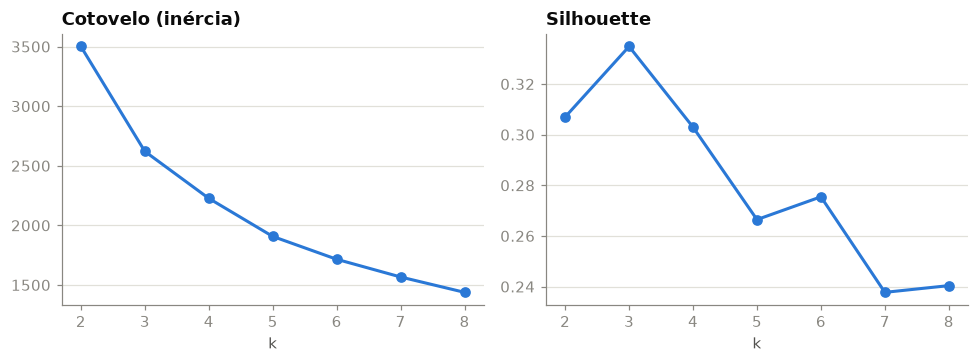

k,2,3,4,5,6,7,8
silhouette,0.307,0.3348,0.303,0.2665,0.2755,0.2377,0.2404


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

features = eligible.assign(
    log_orders=np.log1p(eligible["n_orders"]),
    log_revenue=np.log1p(eligible["revenue"]),
)[["log_orders", "log_revenue", "late_rate", "posting_days"]]
X = StandardScaler().fit_transform(features)

ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(list(ks), inertias, color=ACCENT, linewidth=2, marker="o")
ax1.set_title("Cotovelo (inércia)")
ax1.set_xlabel("k")
ax2.plot(list(ks), silhouettes, color=ACCENT, linewidth=2, marker="o")
ax2.set_title("Silhouette")
ax2.set_xlabel("k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(ks), "silhouette": np.round(silhouettes, 4)}).set_index("k").T

**Escolha: k = 3.** O silhouette tem máximo claro em k=3 (0,335) e o cotovelo da inércia é compatível. Além do critério numérico, k=3 produz grupos com leitura de negócio imediata, verificada a seguir.

In [13]:
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
eligible = eligible.assign(cluster=km.labels_)

profile = eligible.groupby("cluster").agg(
    vendedores=("n_orders", "size"),
    pedidos_mediana=("n_orders", "median"),
    receita_mediana=("revenue", "median"),
    taxa_atraso_media=("late_rate", "mean"),
    postagem_media_dias=("posting_days", "mean"),
)

# Name personas by their profile, not by arbitrary cluster index.
bottleneck = profile["taxa_atraso_media"].idxmax()
engine = profile["pedidos_mediana"].idxmax()
agile = (set(profile.index) - {bottleneck, engine}).pop()
PERSONAS = {
    engine: "Motores de volume",
    agile: "Cauda longa ágil",
    bottleneck: "Gargalos logísticos",
}
eligible["persona"] = eligible["cluster"].map(PERSONAS)
profile.index = profile.index.map(PERSONAS)
profile.round(3)

,vendedores,pedidos_mediana,receita_mediana,taxa_atraso_media,postagem_media_dias
cluster,,,,,
Motores de volume,427,94.0,11821.50,0.060,2.897
Cauda longa ágil,682,18.0,2095.48,0.049,2.602
Gargalos logísticos,128,21.5,4144.49,0.165,7.448


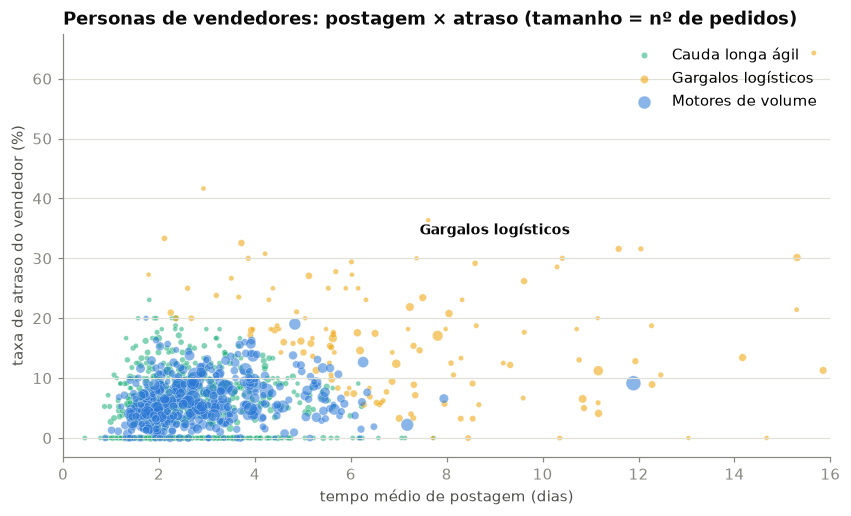

salvo: data/processed/seller_segments.parquet (1,237 vendedores)


In [14]:
PERSONA_COLORS = {"Motores de volume": C1, "Cauda longa ágil": C2, "Gargalos logísticos": C3}

fig, ax = plt.subplots(figsize=(9, 5))
for persona, group in eligible.groupby("persona"):
    ax.scatter(
        group["posting_days"],
        100 * group["late_rate"],
        s=np.sqrt(group["n_orders"]) * 3,
        color=PERSONA_COLORS[persona],
        alpha=0.55,
        label=persona,
        edgecolors="white",
        linewidths=0.3,
    )

ax.annotate(
    "Gargalos logísticos", xy=(9, 34), fontsize=9, fontweight="bold", color=INK, ha="center"
)
ax.set_title("Personas de vendedores: postagem × atraso (tamanho = nº de pedidos)")
ax.set_xlabel("tempo médio de postagem (dias)")
ax.set_ylabel("taxa de atraso do vendedor (%)")
ax.set_xlim(0, 16)
ax.legend(loc="upper right", frameon=False)
plt.show()

segments_path = ROOT / "data" / "processed" / "seller_segments.parquet"
eligible.reset_index().to_parquet(segments_path, index=False)
print(f"salvo: {segments_path.relative_to(ROOT)} ({len(eligible):,} vendedores)")

**As três personas e a leitura de negócio:**

| Persona | Vendedores | Perfil | Leitura |
|---|---|---|---|
| **Motores de volume** | 427 (35%) | mediana de 94 pedidos, receita mediana R$ 11,8 mil, atraso 6,0%, postagem 2,9 dias | Sustentam a operação com desempenho na média; monitorar, não intervir. |
| **Cauda longa ágil** | 682 (55%) | 18 pedidos medianos, atraso 4,9%, postagem 2,6 dias | Pequenos e rápidos; o melhor desempenho relativo da base. |
| **Gargalos logísticos** | 128 (10%) | 21,5 pedidos medianos, **atraso 16,5%**, **postagem 7,4 dias** | 10% dos vendedores com 2,4x a taxa global de atraso e postagem ~3x mais lenta. É onde a gestão de vendedores age primeiro. |

O grupo *Gargalos logísticos* é o insight acionável da segmentação: um conjunto pequeno e identificável de vendedores concentra o risco, e o tempo de postagem lento é o sintoma visível ANTES do atraso se materializar. Isso também motiva as duas features históricas de vendedor da etapa 4 (taxa de atraso e tempo de postagem expansivos): se o passado do vendedor separa personas, deve separar pedidos.

## Lista candidata de features (handoff para a etapa 4)

Consolidação da evidência desta EDA, feature a feature. Todas respeitam o contrato de vazamento do notebook 01 (conhecidas no momento da compra).

| Feature | Evidência da EDA | Expectativa |
|---|---|---|
| `distance_km` (+ flag) | gradiente monotônico 4,6% → 9,7% (P3) | alta |
| `customer_state` (one-hot) | amplitude 4,5% (SP) a 21,4% (AL); RJ 12,1% (P2) | alta |
| `promised_window_days` | não monotônica, pico em 17–22 dias (P4) | alta (árvores) |
| `purchase_month` | sazonalidade forte: nov 12,4%, mar 19,0% (P1) | alta |
| taxa histórica de atraso do vendedor (expansiva, shift) | personas: gargalos com 16,5% vs 4,9% (segmentação) | a mais alta |
| tempo de postagem histórico do vendedor (expansiva, shift) | postagem 7,4 vs 2,6 dias separa personas (segmentação) | alta |
| `main_category` | amplitude 5,4%–8,1% no top-15 (P5) | média |
| `total_weight_g`, `total_volume_cm3` (+ flag) | gradiente fraco 6,1%–7,5% (P7) | baixa/média |
| `n_sellers`, `n_items` | sinal INVERSO ao esperado (P8); o modelo decide | média |
| `freight_price_ratio` | plana isoladamente (P6); mantida por interação | baixa |
| `total_price`, `total_freight`, pagamento (tipo, parcelas) | sem análise dedicada; custo zero, árvores filtram | baixa |

**Próxima etapa (4):** `src/features.py` com as duas features expansivas deslocadas do vendedor (o ponto técnico central do projeto), split temporal, e os três modelos.

## Conclusões

1. **O atraso não é estacionário** (3% a 19% ao mês): sazonalidade e choques exigem split temporal e monitoramento em produção.
2. **Geografia domina o problema:** distância e UF de destino têm os gradientes mais limpos; RJ é o mercado grande com pior desempenho.
3. **O atraso é relativo à promessa:** a relação não monotônica da janela prometida e o caso multi-vendedor mostram que o alvo mede a qualidade da CALIBRAÇÃO da promessa, não só a velocidade da logística.
4. **O risco de vendedor é concentrado e visível antes do atraso:** 10% dos vendedores (gargalos) têm 2,4x a taxa global, com postagem lenta como sintoma precoce, a motivação empírica das features históricas da etapa 4.
5. **Honestidade registrada:** frete/preço e peso têm sinal fraco ou nulo isoladamente; ficam na lista por custo zero, sem promessas.